#  Hypothesis Testing Activity <hr style="border:2.5px solid #d57f15"></hr>

<b>Francis Roi F. Buenacosa</b>
<br>Computer Engineer/Technician

In [6]:
# imports and packages
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

In [7]:
# load dataset
df = pd.read_csv(r"StudentsPerformance.csv",
                 delimiter=",")
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [8]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [9]:
# summary of statistics
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#  DATA CLEANING

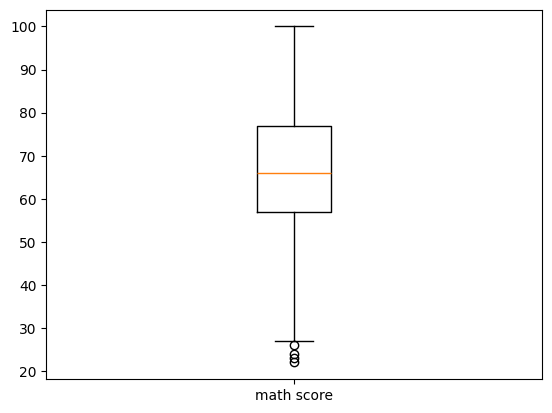

In [12]:
# math score
plt.boxplot(df['math score'],tick_labels=['math score'])
plt.show()

In [11]:
# removing 3-sigma outliers
z_math = stats.zscore(df['math score'])
ms_outliers = (z_math<-3)|(z_math>3)
df = df[~ms_outliers]

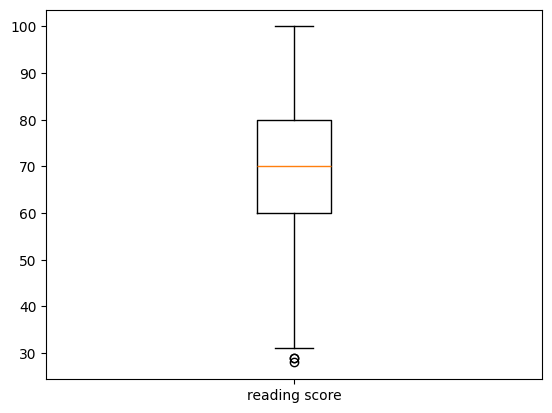

In [15]:
# reading score
# removing 3-sigma outliers
z_reading = stats.zscore(df['reading score'])
rs_outliers = (z_reading<-3)|(z_reading>3)
df = df[~rs_outliers]

plt.boxplot(df['reading score'],tick_labels=['reading score'])
plt.show()

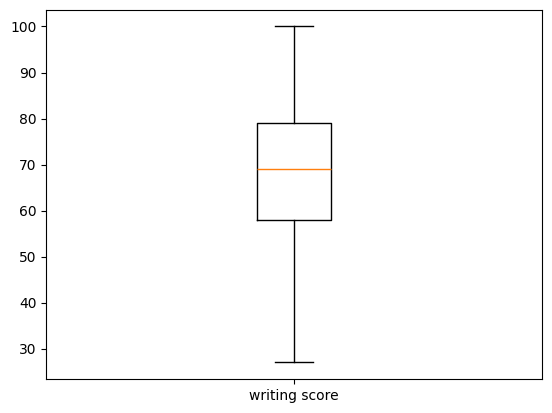

In [16]:
# writing score
# removing 3-sigma outliers
z_writing = stats.zscore(df['writing score'])
ws_outliers = (z_writing<-3)|(z_writing>3)
df = df[~ws_outliers]

plt.boxplot(df['writing score'],tick_labels=['writing score'])
plt.show()

In [17]:
# save cleaned dataset
df.to_csv(r"StudentsPerformance-cleaned.csv",
          index=False)

In [18]:
# load dataset
df = pd.read_csv(r"StudentsPerformance-cleaned.csv",
                 delimiter=",")
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
988,female,group E,master's degree,standard,completed,88,99,95
989,male,group C,high school,free/reduced,none,62,55,55
990,female,group C,high school,free/reduced,completed,59,71,65
991,female,group D,some college,standard,completed,68,78,77


In [19]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       993 non-null    object
 1   race/ethnicity               993 non-null    object
 2   parental level of education  993 non-null    object
 3   lunch                        993 non-null    object
 4   test preparation course      993 non-null    object
 5   math score                   993 non-null    int64 
 6   reading score                993 non-null    int64 
 7   writing score                993 non-null    int64 
dtypes: int64(3), object(5)
memory usage: 62.2+ KB


In [20]:
# summary of statistics
df.describe()

,math score,reading score,writing score
count,993.000000,993.000000,993.000000
mean,66.420947,69.471299,68.383686
std,14.661917,14.188799,14.719241
min,22.000000,28.000000,27.000000
25%,57.000000,60.000000,58.000000
50%,66.000000,70.000000,69.000000
75%,77.000000,80.000000,79.000000
max,100.000000,100.000000,100.000000


# 2 Sample t-Test

# Reading Score and Writing Score

In [21]:
df[['reading score','writing score']].describe()

,reading score,writing score
count,993.000000,993.000000
mean,69.471299,68.383686
std,14.188799,14.719241
min,28.000000,27.000000
25%,60.000000,58.000000
50%,70.000000,69.000000
75%,80.000000,79.000000
max,100.000000,100.000000


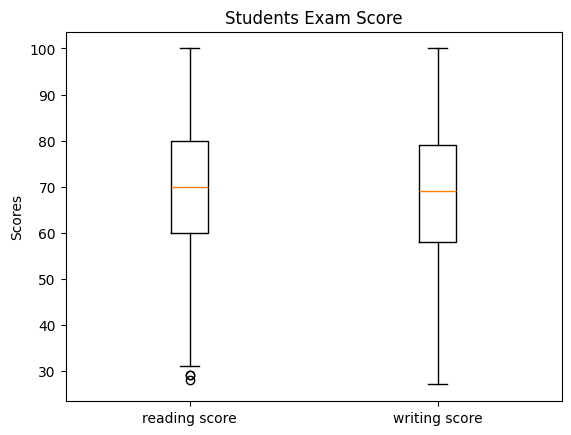

In [22]:
# check for outliers
plt.boxplot(df[['reading score','writing score']],tick_labels=['reading score','writing score'])
plt.title("Students Exam Score")
plt.ylabel('Scores')
plt.show()

In [23]:
# shapiro-wilk normality test
print("reading score:")
w_stat, p_value = stats.shapiro(df['reading score'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")
    
print("\nwriting score:")
w_stat, p_value = stats.shapiro(df['writing score'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

reading score:
w_stat: 0.9942
P-value: 0.0007
Non-normal data

writing score:
w_stat: 0.9932
P-value: 0.0002
Non-normal data


In [24]:
"""
F-Test for equality of variances
--------------------------------
Ho: var_rs = var_ws
Ha: var_rs != var_ws
"""

var_rs = df['reading score'].var(ddof=1)
var_ws = df['writing score'].var(ddof=1)

# F-statistic
if var_rs > var_ws:
    f_stat = var_rs/var_ws
else:
    f_stat = var_ws/var_rs

print(f'f_stat = {f_stat:.4f}')

# Degrees of Freedom
dof_rs = df['reading score'].count()-1
dof_ws = df['writing score'].count()-1

# probability value
p_value = 1 - stats.f.cdf(f_stat, dof_rs, dof_ws)
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("unequal variances")
else:
    # fail to reject null hypothesis
    print("equal variances")

f_stat = 1.0762
p_value = 0.1239
equal variances


In [25]:
"""
2- Sample T-Test for Independent Samples
----------------------------------------
Ho: Reading Score <= Writing Score
Ha: Reading Score > Writing Score
"""

t_stat, p_value = stats.ttest_ind(df['reading score'],df['writing score'],
                                  alternative='greater',
                                  equal_var=True)

print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Reading scores are higher than writing scores.")
    # fail to reject null hypothesis
else:
    print("There is no significant difference between reading scores and writing scores.")

t_stat = 1.6764
p_value = 0.0469
Reading scores are higher than writing scores.


In [26]:
"""
left-tailed test
------------------
Ho: u_reading = u_writing
Ha: u_reading > u_writing
"""
    
# cohen's d
reading_mean = df['reading score'].mean()
writing_mean = df['writing score'].mean()
reading_std = df['reading score'].std(ddof=1)

d = abs((reading_mean - writing_mean)/reading_std)

print(f"Cohen's d: {d:.4f}")

# power of a test
power = TTestPower().power(
    effect_size = -d, # difference must be negative for alternative='smaller'
    nobs = df['reading score'].count(),
    alpha = 0.05,
    alternative = "smaller"
)

print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 0.0767
Power of the test: 77.90%
